<h3>Лабораторная работа №1</h3>
<h4>А-01м-25 Енгоян Сергей</h4>
<h4>Разведочный анализ датасета "Влияние ИИ на студентов"</h4>

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle

<h3>Загружаем датасет</h3>

In [81]:
# dataset https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students

df = pd.read_csv('../data/ai_student_impact_dataset.csv')

In [82]:
df.head(20)

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium
5,100006,STEM,Junior,3.449,6.50,Debugging/Troubleshooting,Beginner,1,False,14.19,4,Allowed_With_Citation,5,3.666,65.92,High
6,100007,STEM,Freshman,3.622,31.41,Summarizing_Reading,Advanced,5,True,13.11,8,Allowed_With_Citation,7,4.000,67.97,Medium
7,100008,Arts,Junior,2.746,5.33,Copywriting/Drafting,Intermediate,3,False,18.45,2,Actively_Encouraged,1,2.965,85.09,Medium
8,100009,Business,Sophomore,3.420,2.00,Debugging/Troubleshooting,Beginner,2,True,2.87,1,Strict_Ban,5,3.396,55.71,Medium
9,100010,Business,Sophomore,3.046,19.99,Debugging/Troubleshooting,Intermediate,2,True,12.49,3,Strict_Ban,8,2.978,87.18,High


- Major_Category - Специализация
- Year_of_Study - Год обучения
- Primary_Use_Case - Основное назначение использования ИИ
- Prompt_Engineering_Skill - Уровень навыка использования ИИ
- Tool_Diversity - Кол-во разнообразных используемых ИИ
- Paid_Subscription - Куплена ли подписка на ИИ
- Traditional_Study_Hours - Часы традиционной учёбы в неделю
- Weekly_GenAI_Hours - Часы использования GenAI в неделю
- Perceived_AI_Dependency - Воспринимаемая зависимость от ИИ
- Anxiety_Level_During_Exams - Уровень тревожности во время экзаменов
- Burnout_Risk_Level - Рискк выгорания
- Pre_Semester_GPA - GPA в начале семестра
- Post_Semester_GPA - GPA после семестра
- Skill_Retention_Score - Оценка сохранения навыков
- Institutional_Policy - Политика использования ИИ в учебном заведении

In [83]:
df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

<h3>Очистка данных</h3>

In [84]:
# Обозначим категориальные столбцы

categorical_cols = [
    'Major_Category', 
    'Year_of_Study', 
    'Primary_Use_Case',
    'Prompt_Engineering_Skill', 
    'Institutional_Policy',
    'Burnout_Risk_Level'
]

df[categorical_cols] = df[categorical_cols].astype('category')

df['Year_of_Study'] = df['Year_of_Study'].cat.reorder_categories(
    ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'], ordered=True)
df['Prompt_Engineering_Skill'] = df['Prompt_Engineering_Skill'].cat.reorder_categories(
    ['Beginner', 'Intermediate', 'Advanced'], ordered=True)
df['Burnout_Risk_Level'] = df['Burnout_Risk_Level'].cat.reorder_categories(
    ['Low', 'Medium', 'High'], ordered=True)

In [85]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 3.77 MB


In [86]:
# Даункаст

df['Student_ID'] = df['Student_ID'].astype('int32')
df['Tool_Diversity'] = df['Tool_Diversity'].astype('int8')
df['Perceived_AI_Dependency'] = df['Perceived_AI_Dependency'].astype('int8')
df['Anxiety_Level_During_Exams'] = df['Anxiety_Level_During_Exams'].astype('int8')

float_cols = [
    'Pre_Semester_GPA',
    'Post_Semester_GPA',
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
    'Skill_Retention_Score'
]
df[float_cols] = df[float_cols].astype('float32')


In [87]:
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.62 MB


In [88]:
df = df.drop(columns = ['Student_ID'])
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.43 MB


In [89]:
# Уберем некоторые краевые значения

# df = df[df['Skill_Retention_Score'].between(20, 95)]
# df = df[df['Weekly_GenAI_Hours'].between(0, 38)]
print(f"Память: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Память: 1.43 MB


<h3>EDA</h3>

In [90]:
df.describe()

,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798126
std,0.478854,8.269489,1.18802,5.156426,1.820812,2.144066,0.495673,13.281627
min,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190002
max,3.998000,40.000000,5.00000,35.860001,10.000000,10.000000,4.000000,100.000000


In [91]:
cat_features = df.select_dtypes(include=['category'])
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


In [92]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [93]:
for cat in cat_features:
    print(f'{cat} - numer of unique = {df[cat].nunique()}')

Major_Category - numer of unique = 5
Year_of_Study - numer of unique = 5
Primary_Use_Case - numer of unique = 5
Prompt_Engineering_Skill - numer of unique = 3
Institutional_Policy - numer of unique = 3
Burnout_Risk_Level - numer of unique = 3


In [94]:
for col in cat_features:
    print(f'Unique categories in {df[col].value_counts()}\n\n')

Unique categories in Major_Category
STEM          15059
Business      12538
Humanities     9994
Medical        6476
Arts           5933
Name: count, dtype: int64


Unique categories in Year_of_Study
Junior       11045
Freshman     11031
Senior       10634
Sophomore     9860
Graduate      7430
Name: count, dtype: int64


Unique categories in Primary_Use_Case
Debugging/Troubleshooting    12295
Copywriting/Drafting         12011
Ideation                     10721
Summarizing_Reading           8633
Direct_Answer_Generation      6340
Name: count, dtype: int64


Unique categories in Prompt_Engineering_Skill
Beginner        18495
Intermediate    17696
Advanced        13809
Name: count, dtype: int64


Unique categories in Institutional_Policy
Allowed_With_Citation    25224
Actively_Encouraged      14988
Strict_Ban                9788
Name: count, dtype: int64


Unique categories in Burnout_Risk_Level
Medium    21144
Low       16369
High      12487
Name: count, dtype: int64




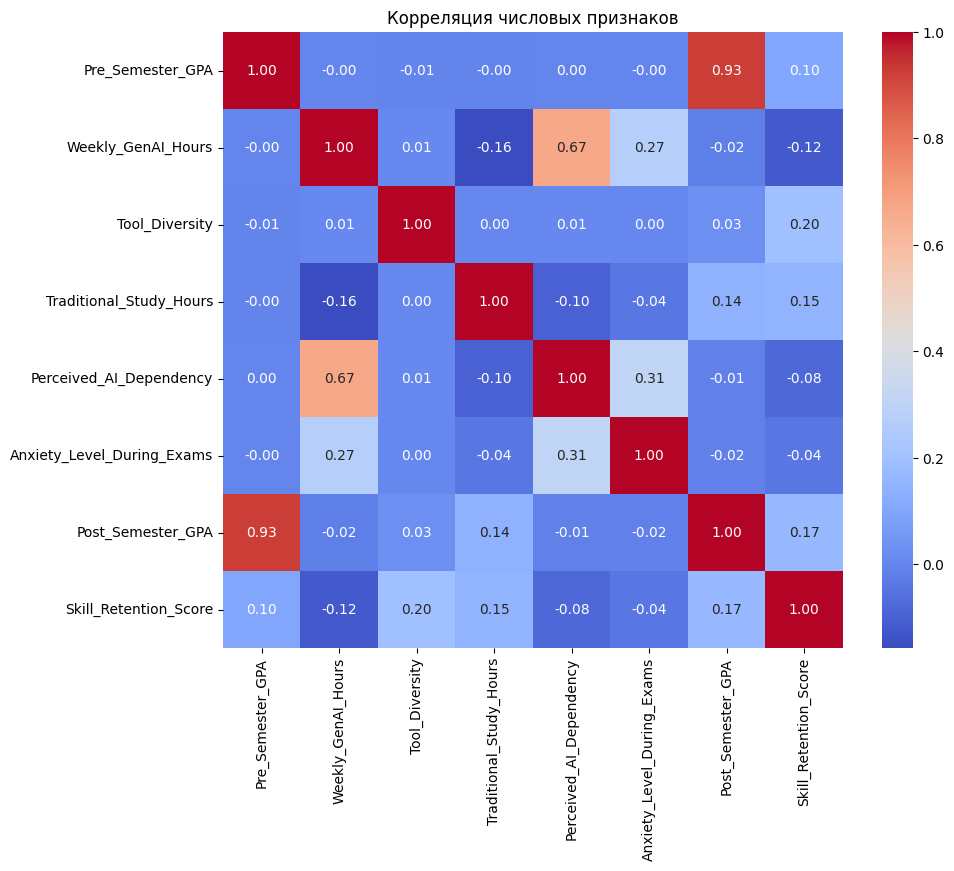

In [95]:
# Корреляция числовых фичей

plt.figure(figsize=(10, 8))
feature_correlation = num_features.corr()
sns.heatmap(feature_correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Корреляция числовых признаков')
plt.show()

Корреляции:
- Очевидная зависимость оценки в начале семестра и в конце (Pre/Post_Semester_GPA)
- Большая корреляция Зависимости студента от ИИ и часов использования ИИ (Weekly_GenAI_Hours и Perceived_AI_Dependency)

<p></p>

- Skill_Retention_Score прямо зависит от оценок в начале семестра и в конце (Pre/Post_Semester_GPA)
- Skill_Retention_Score прямо зависит от количества разных используемых ИИ инструментов (Tool_Diversity)
- Skill_Retention_Score обратная зависимость от кол-ва часов использования ИИ (Weekly_GenAI_Hours) и прямо от традиционных часов на учебу (Traditional_Study_Hours)

<p></p>


- Прямая корреляция часов использования ИИ/Зависимости от ИИ и степени тревожности на экзамене (Weekly_GenAI_Hours/Perceived_AI_Dependency и Anxiety_Level_During_Exams)
- Обратная корреляция часов использования ИИ и традиционных часов на учебу (Weekly_GenAI_Hours и Traditional_Study_Hours)

<p></p>

<b>Можем предположить, что использование ИИ обратно сказывается на успеваемости студента с точки зрения усваивания знаний по предмету, а также повышает тревожность на экзамене. 

In [96]:
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


In [97]:
print(cat_features.columns.to_list())

['Major_Category', 'Year_of_Study', 'Primary_Use_Case', 'Prompt_Engineering_Skill', 'Institutional_Policy', 'Burnout_Risk_Level']


C:\Users\User\AppData\Local\Temp\ipykernel_27044\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27044\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27044\2665855403.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


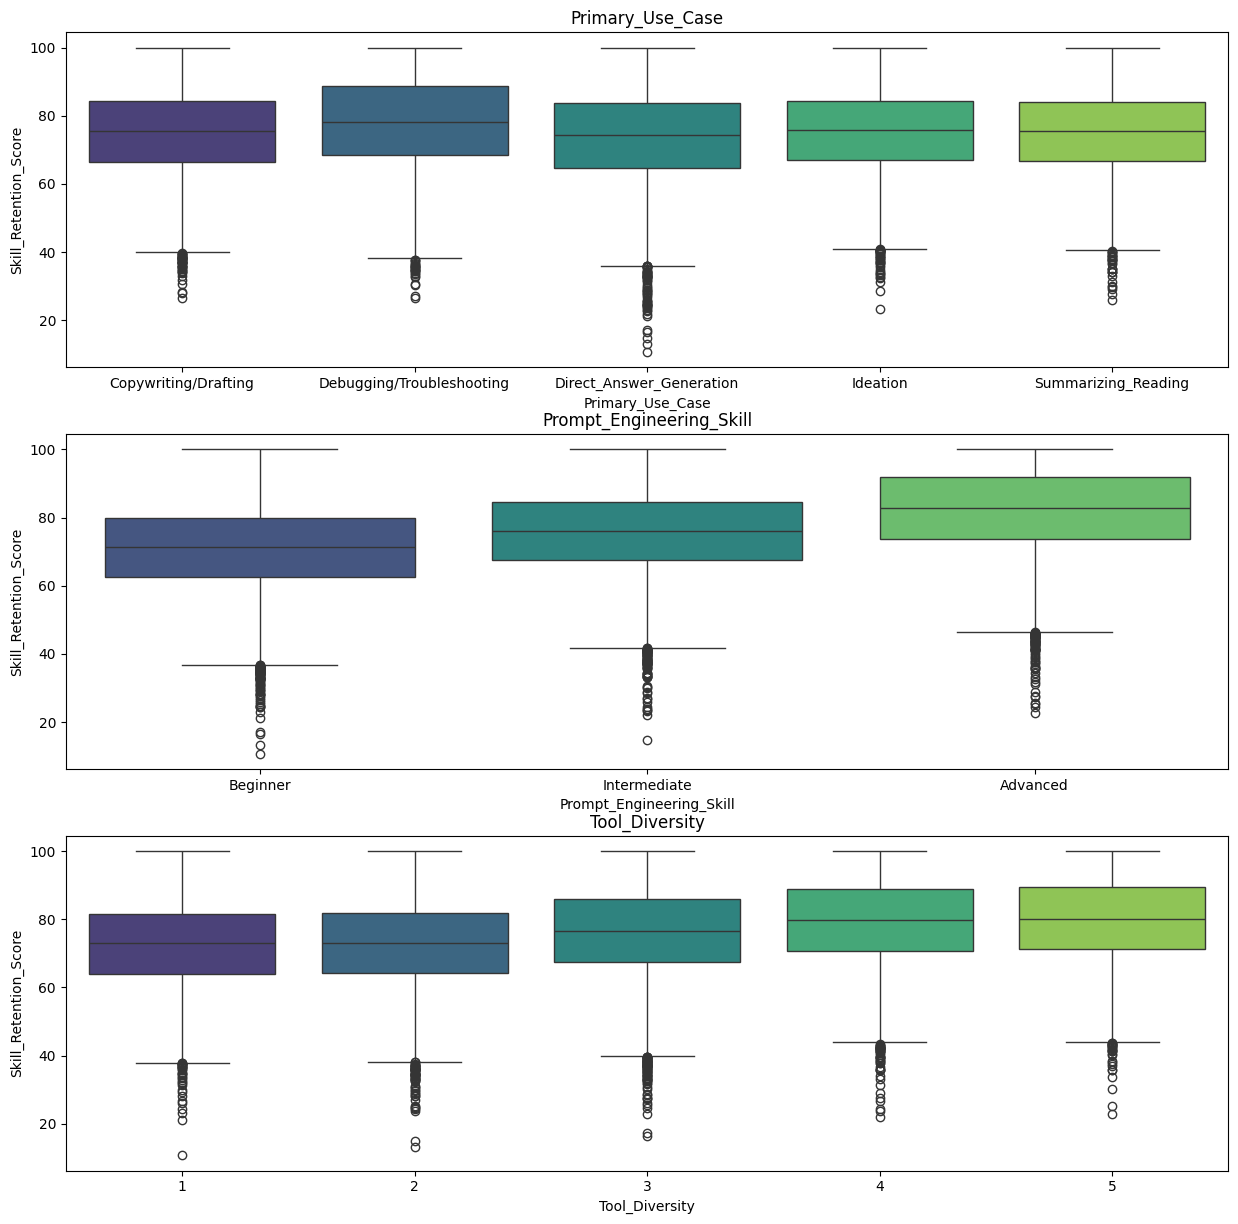

In [98]:
# Ящики с усами по категорияльным признакам и Skill_Retention_Score

plt.figure(figsize=(15, 20))

cols = [
    'Primary_Use_Case',
    'Prompt_Engineering_Skill',
    'Tool_Diversity'
]

for num, col in enumerate(cols):
    plt.subplot(4, 1, num+1)
    sns.boxplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            palette="viridis",
        )
    plt.title(col)

plt.show()

Заметим, что худший результат показали студенты, использующие ИИ для получения конечного ответа. Они же показали наибольшее кол-во выбросов с низким усвоением материала.<p>
Но студенты, обладающие лучшими навыками владения ИИ и использующие больше разнообразных инструментов, имеют лучшие результаты.<p>
<b>Предположим, что бездумное использование ИИ ухудшает усвоение материала, а умелое напротив - повышает результативность.

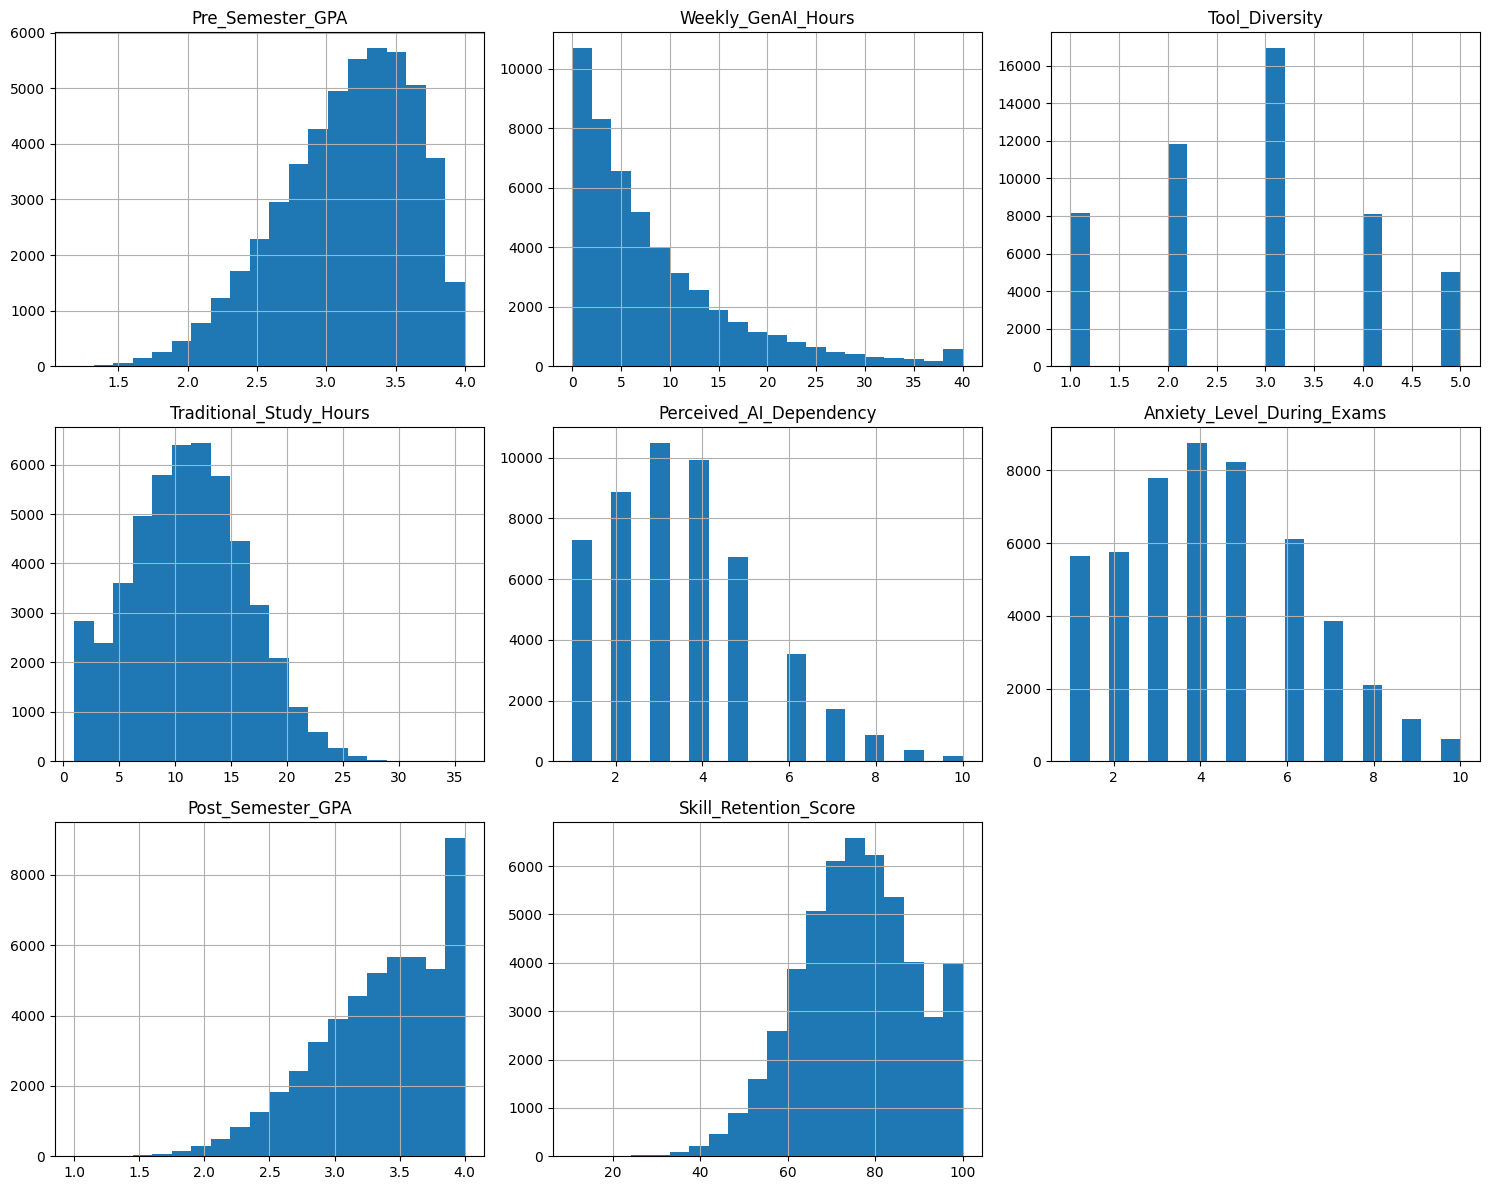

In [99]:
# Гистограммы по числовым признакам

df.hist(figsize=(15, 12), bins=20)
plt.tight_layout()
plt.show()

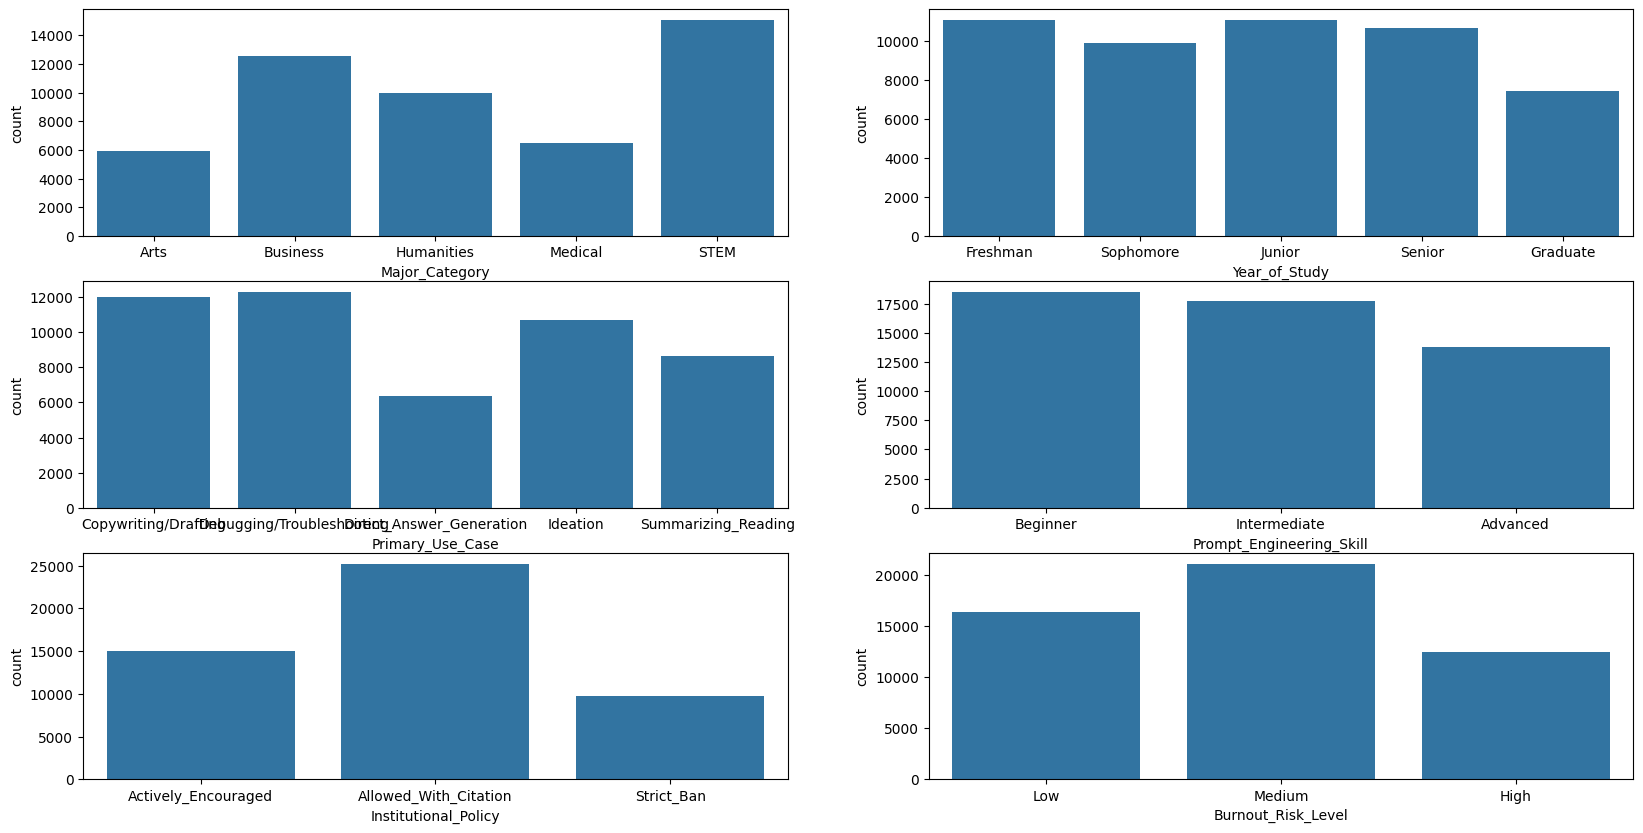

In [100]:
# Countplot по категорийным признакам

plt.figure(figsize=(20, 10))
for i, col in enumerate(df.select_dtypes('category').columns):
    plt.subplot(3,2,i+1)
    sns.countplot(data=df, x=col)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_27044\3250317331.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27044\3250317331.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'Burnout_Risk_Level - Weekly_GenAI_Hours')

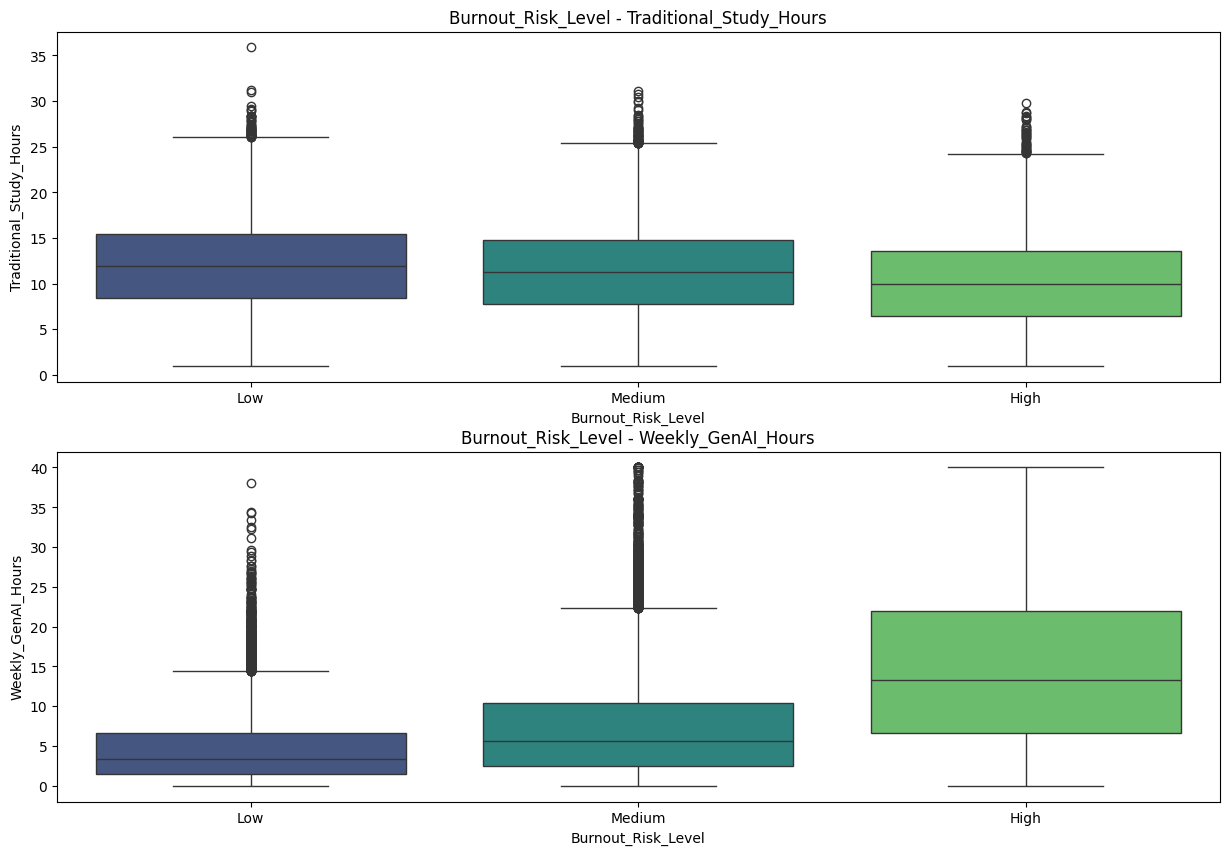

In [101]:
# Ящики с усами - время традиционного обучения и с ИИ

plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Traditional_Study_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Traditional_Study_Hours')

plt.subplot(2, 1, 2)
sns.boxplot(
        data=df,
        x='Burnout_Risk_Level',
        y="Weekly_GenAI_Hours",
        palette="viridis",
    )
plt.title('Burnout_Risk_Level - Weekly_GenAI_Hours')

<b>Студенты черезмерно использующие ИИ имеют высокую степень риска выгорания

In [102]:
num_features = df.select_dtypes(include=[np.number])
print(num_features.columns.to_list())

['Pre_Semester_GPA', 'Weekly_GenAI_Hours', 'Tool_Diversity', 'Traditional_Study_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Post_Semester_GPA', 'Skill_Retention_Score']


C:\Users\User\AppData\Local\Temp\ipykernel_27044\2944600634.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27044\2944600634.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


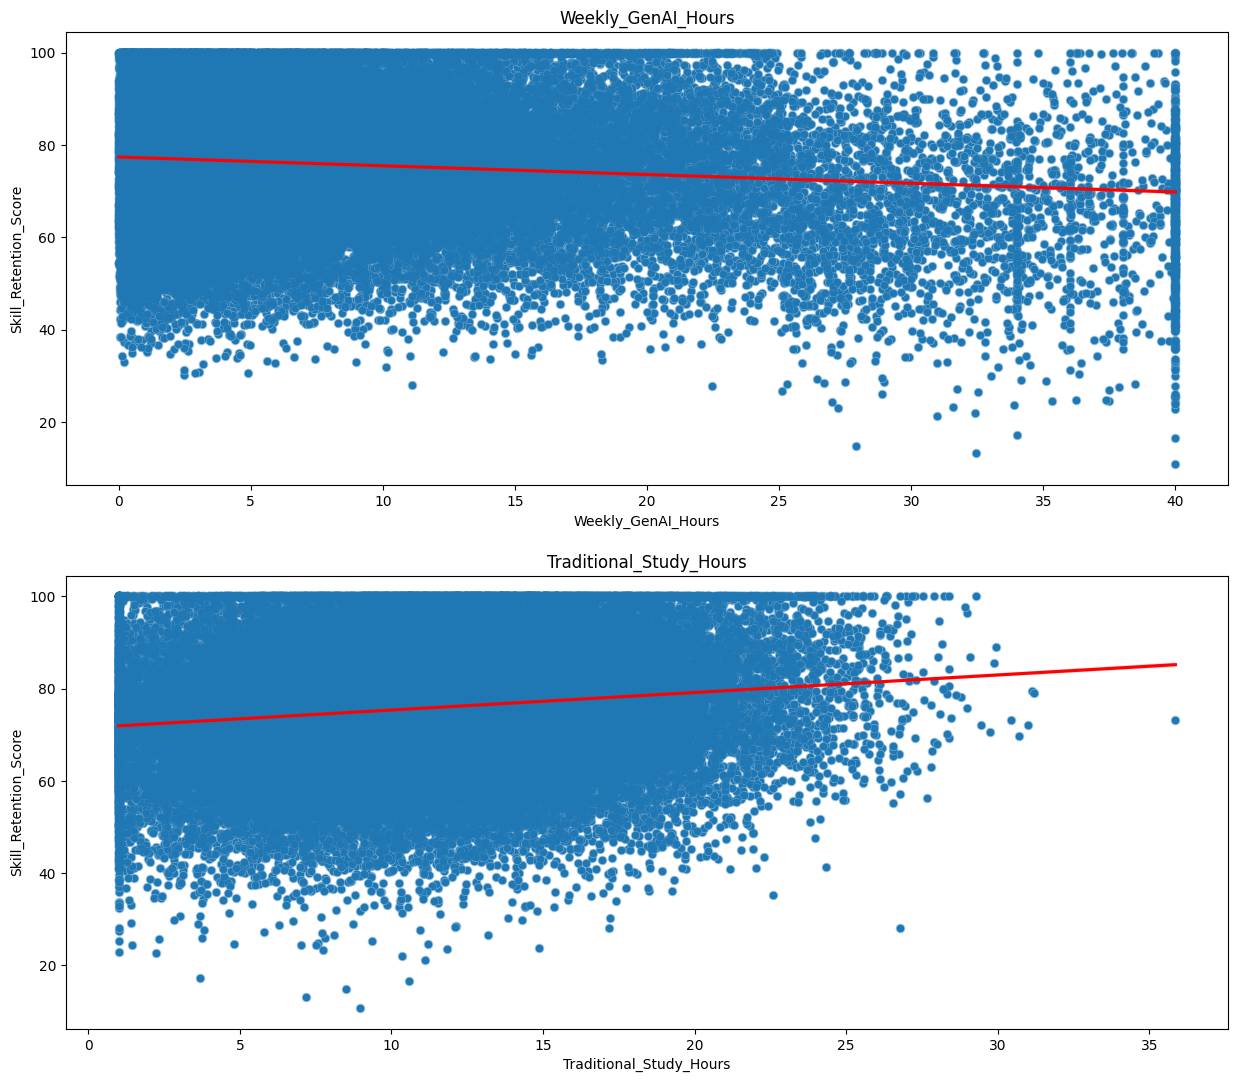

In [103]:
# Зависимость времени традиционного обучения и использования ИИ на усвоение материала

plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="Skill_Retention_Score",
            # y="Post_Semester_GPA",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="Skill_Retention_Score",
        # y="Post_Semester_GPA",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

При повышении традиционных часов на обучение повышается и минимальный уровень освоения материала.<p>
При излишнем использовании ИИ (примерно >25ч в неделю) усваиваемость начинает падать.<p>
<b>Предположим, что черезмерное использование ИИ может вредить успеваемости

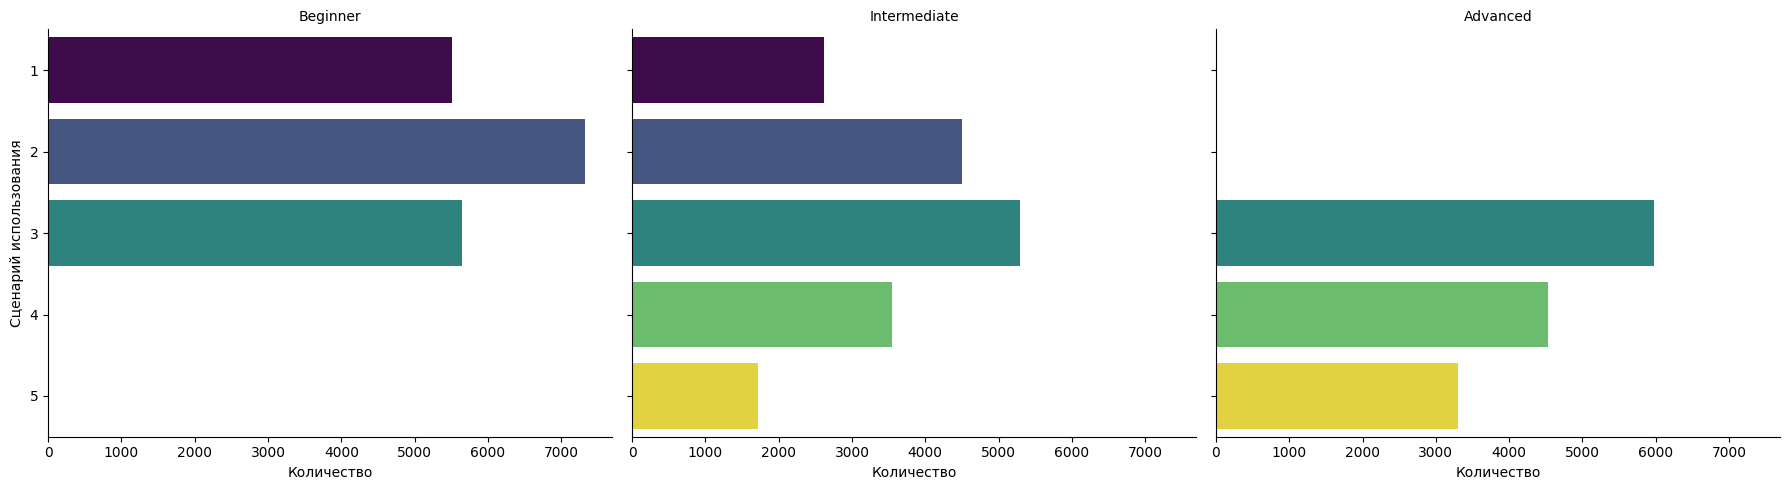

In [104]:
g = sns.catplot(
    data=df,
    y="Tool_Diversity",       # Названия кейсов по вертикали (чтобы текст читался)
    hue="Tool_Diversity",     # Красим каждый кейс в свой цвет (опционально)
    kind="count",               # Считаем количество строк
    col="Prompt_Engineering_Skill", # Для каждого навыка — своя колонка
    col_wrap=3,                 # Если навыков много, переносим на новую строку (например, по 3 в ряд)
    height=5,                   # Высота каждого подграфика
    aspect=1.2,                 # Пропорции (ширина = height * aspect)
    palette="viridis",          # Приятная цветовая палитра
    legend=False                # Отключаем общую легенду, так как оси Y подписаны
)

# Настройка заголовков подграфиков
g.set_titles("{col_name}")
g.set_axis_labels("Количество", "Сценарий использования")

plt.tight_layout()
plt.show()

In [105]:
# Введем новые информативные признаки

df['GPA_Delta'] = df['Post_Semester_GPA'] - df['Pre_Semester_GPA']     # Разница между началом и концом года
df['Academic_Perfomance_Drop'] = df['GPA_Delta'] < 0                    # Было ли ухудшение успеваемости

df['High_Risk_Student'] = (
    (df['Burnout_Risk_Level'] == 'High') & \
    (df['Anxiety_Level_During_Exams'] > 7)
)                                                                       # Находится ли стундент в зоне риска

df['Total_Stud_Hours'] = df['Traditional_Study_Hours'] + df['Weekly_GenAI_Hours']   # Все время обучения в неделю
df['AI_Usage_Percentage'] = df['Weekly_GenAI_Hours'] / df['Total_Stud_Hours']       # Доля использования ИИ от всего времени обучения

C:\Users\User\AppData\Local\Temp\ipykernel_27044\46561556.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\User\AppData\Local\Temp\ipykernel_27044\46561556.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


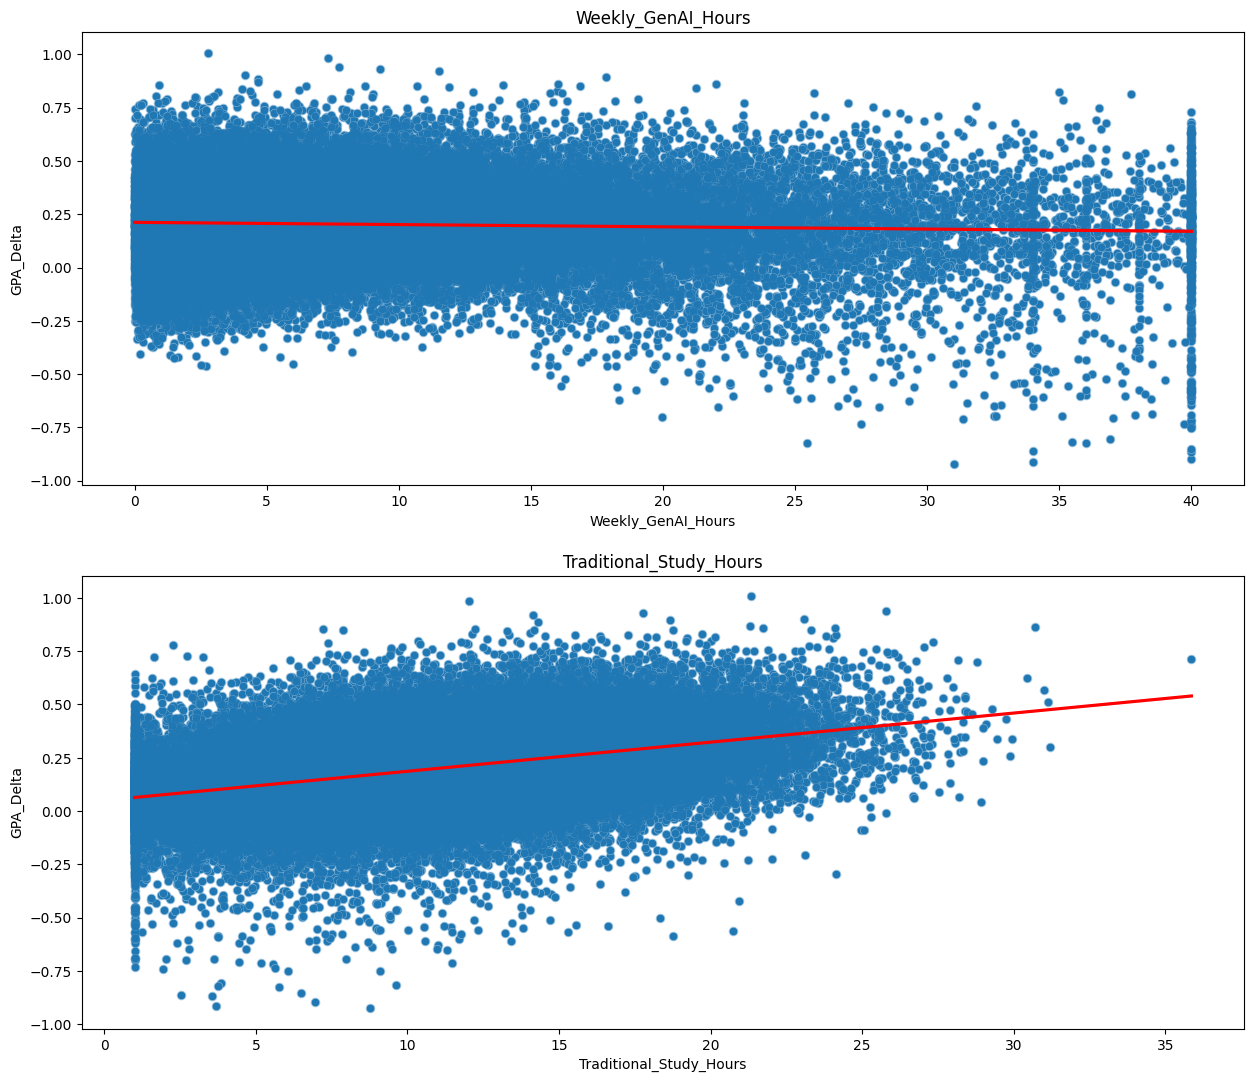

In [106]:
plt.figure(figsize=(15, 20))

cols = [
    'Weekly_GenAI_Hours',
    'Traditional_Study_Hours',
]

for num, col in enumerate(cols):
    plt.subplot(3, 1, num+1)
    sns.scatterplot(
            data=df,
            x=col,
            y="GPA_Delta",
            palette="viridis",
        )
    sns.regplot(
        data=df, 
        x=col, 
        y="GPA_Delta",
        scatter_kws={'alpha':0.3},
        line_kws={'color': 'red'}
    )
    plt.title(col)

plt.show()

Студенты, больше занимающиеся традиционно, улучшали свои показатели к концу года. <p>
Студенты, черезмерно использовавшие ИИ, чаще ухудшали свои показатели к концу года

C:\Users\User\AppData\Local\Temp\ipykernel_27044\3689839277.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Text(0.5, 1.0, 'High_Risk_Student - Perceived_AI_Dependency')

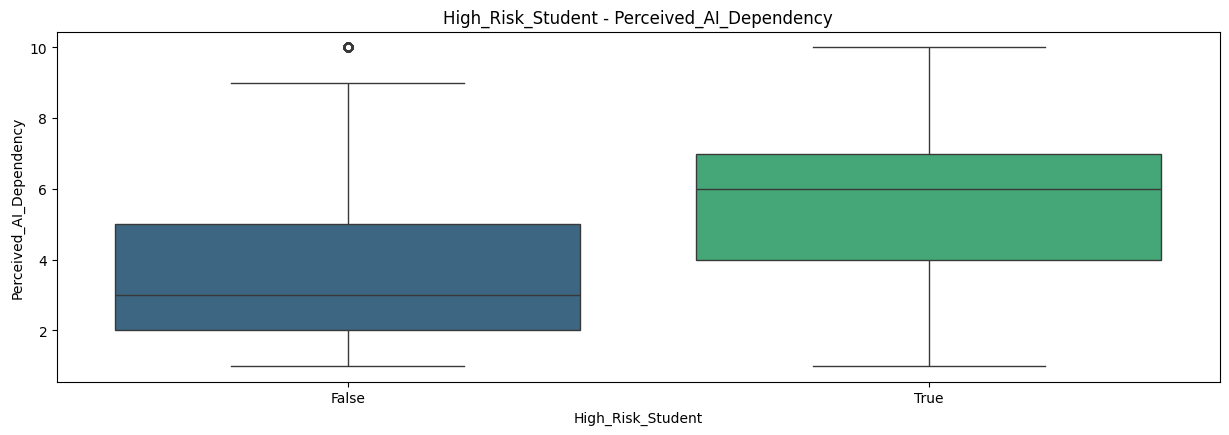

In [107]:
plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.boxplot(
        data=df,
        x='High_Risk_Student',
        y="Perceived_AI_Dependency",
        palette="viridis",
    )
plt.title('High_Risk_Student - Perceived_AI_Dependency')

C:\Users\User\AppData\Local\Temp\ipykernel_27044\1026816512.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


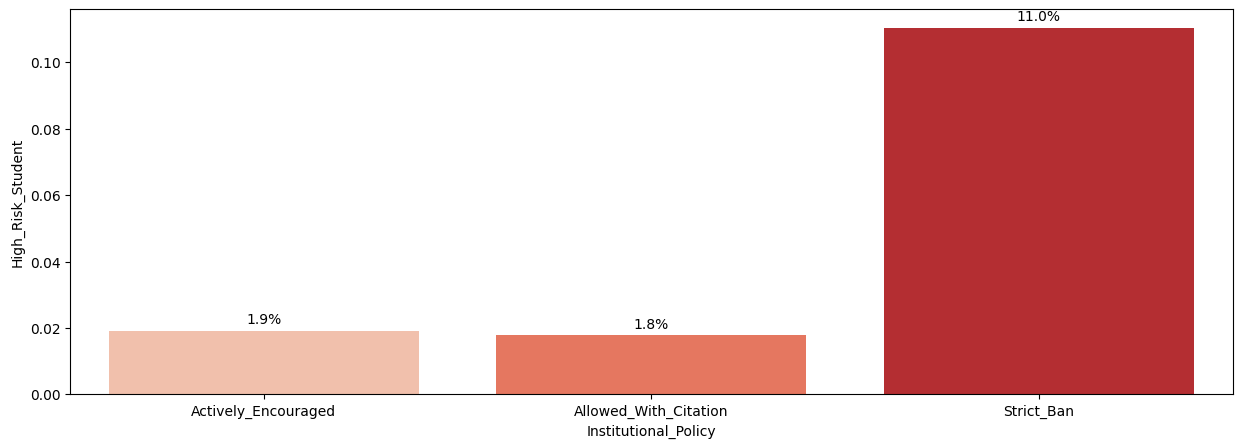

C:\Users\User\AppData\Local\Temp\ipykernel_27044\1026816512.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


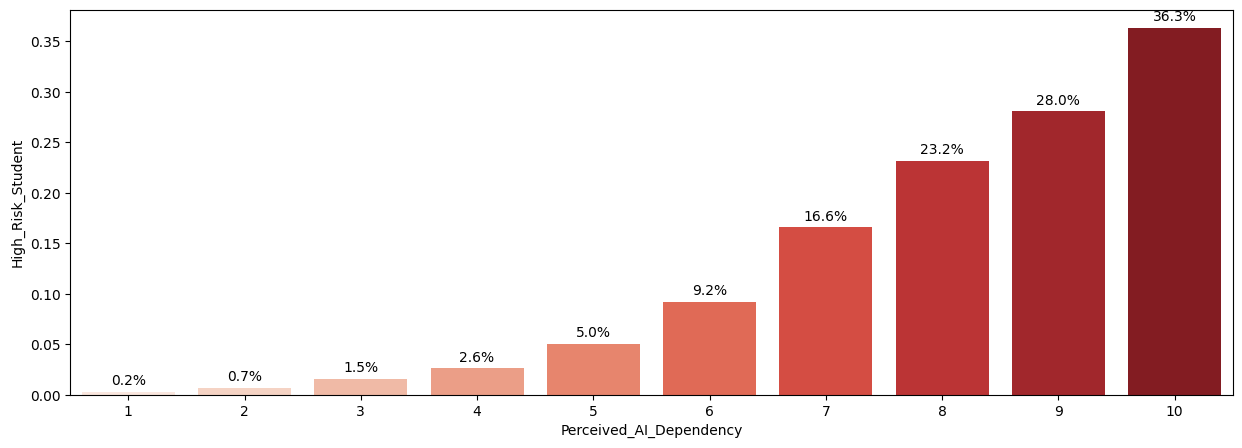

C:\Users\User\AppData\Local\Temp\ipykernel_27044\1026816512.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


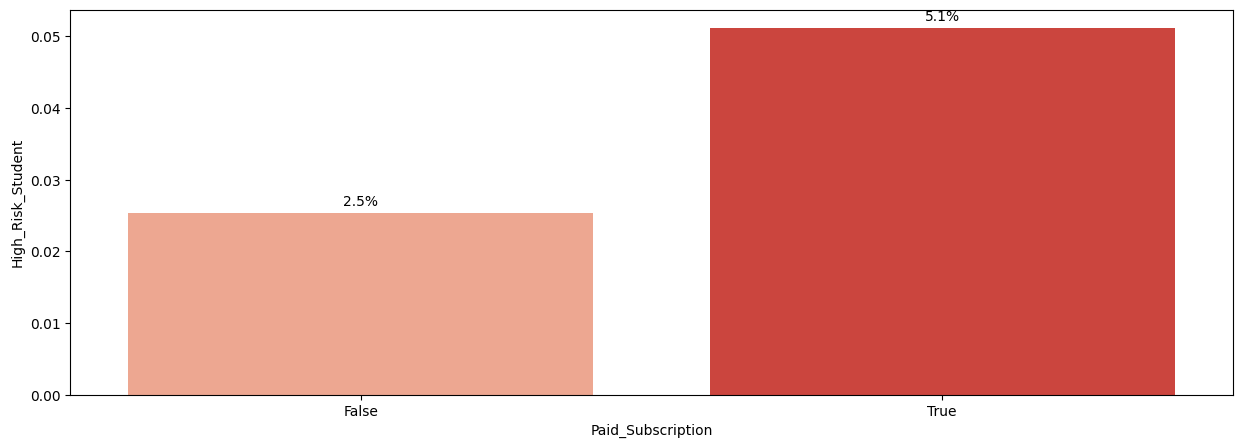

C:\Users\User\AppData\Local\Temp\ipykernel_27044\1026816512.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


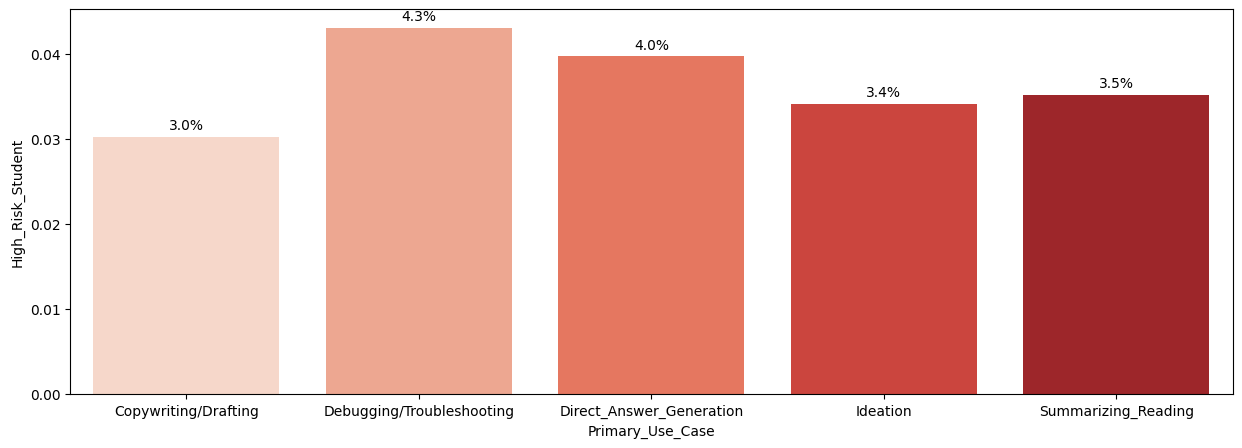

In [108]:
cols = [
    'Institutional_Policy',
    'Perceived_AI_Dependency',
    'Paid_Subscription',
    'Primary_Use_Case'
]

for col in cols:
    plt.figure(figsize=(15, 5))
    ax = sns.barplot(
        data=df, 
        x=col, 
        y="High_Risk_Student",
        palette="Reds",
        errorbar=None
    )

    for container in ax.containers:
        ax.bar_label(container, fmt=lambda x: f'{x*100:.1f}%', padding=3)
    plt.show()

Проанализировав студентов в зоне риска (Высокий уровень выгорания и высокий уровень стресса на экзамене) можно сделать выводы:
- Чем старше курс, тем больше студентов в зоне риска
- Строгий запрет ИИ способствует сильному росту студентов в зоне риска (использование ИИ против правил ВУЗа?)
- Степень зависимости от ИИ коррелирует с процентом студентов в зоне риска

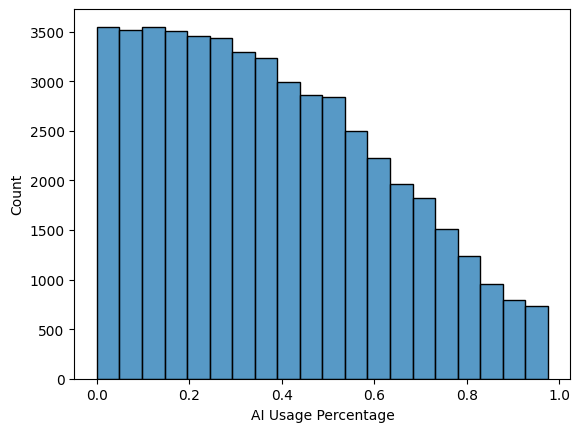

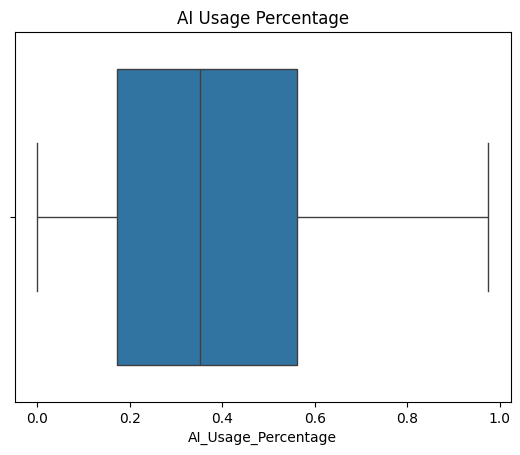

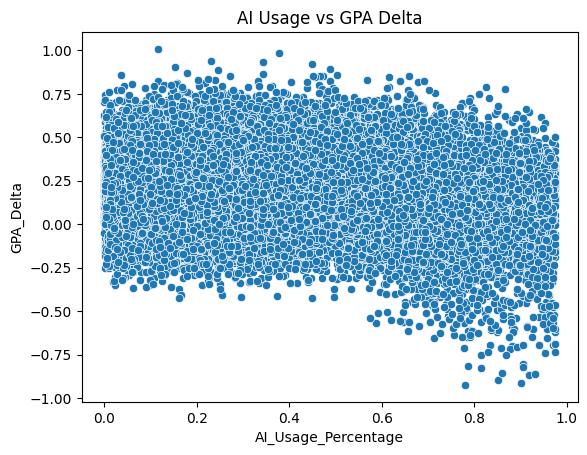

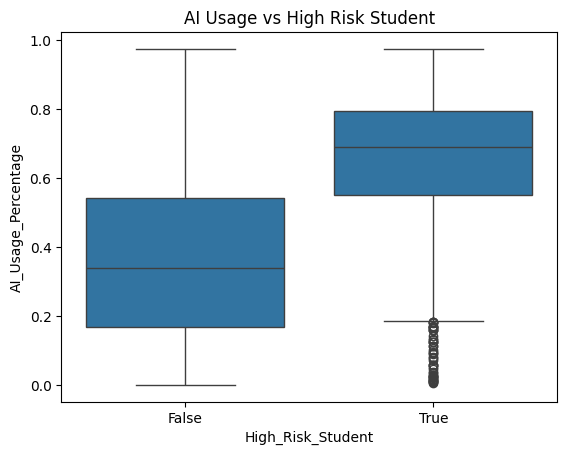

In [109]:
# 1. Распределение
sns.histplot(df['AI_Usage_Percentage'], bins=20)
plt.xlabel('AI Usage Percentage')
plt.show()

# 2. Boxplot
sns.boxplot(x=df['AI_Usage_Percentage'])
plt.title('AI Usage Percentage')
plt.show()

# 3. AI Usage - GPA Delta
sns.scatterplot(data=df, x='AI_Usage_Percentage', y='GPA_Delta')
plt.title('AI Usage vs GPA Delta')
plt.show()

# 4. AI Usage - High Risk Student
sns.boxplot(data=df, x='High_Risk_Student', y='AI_Usage_Percentage')
plt.title('AI Usage vs High Risk Student')
plt.show()



Групповые операции

In [110]:
def flat_index(df_stats): 
    df_stats.columns = df_stats.columns.get_level_values(0) + '_' +  df_stats.columns.get_level_values(1) 
    df_stats.columns = df_stats.columns.to_flat_index() 
    df_stats.reset_index(inplace=True) 
    return df_stats

In [111]:
num_features = df.select_dtypes(include=[np.number])
num_features.columns.to_list()

['Pre_Semester_GPA',
 'Weekly_GenAI_Hours',
 'Tool_Diversity',
 'Traditional_Study_Hours',
 'Perceived_AI_Dependency',
 'Anxiety_Level_During_Exams',
 'Post_Semester_GPA',
 'Skill_Retention_Score',
 'GPA_Delta',
 'Total_Stud_Hours',
 'AI_Usage_Percentage']

In [112]:
df['AI_Usage_Group'] = pd.cut(
    df['AI_Usage_Percentage'],
    bins=[-0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.01],
    labels=['<10%', '<20%', '<30%',  '<40%', '<50%', '<60%', '<70%', '<80%', '<90%', '<100%']
)

In [113]:
aggregated_df = df[num_features.columns.to_list() + ['AI_Usage_Group']].groupby(by='AI_Usage_Group').agg(['mean', 'std'])
aggregated_df = flat_index(aggregated_df)
aggregated_df 

C:\Users\User\AppData\Local\Temp\ipykernel_27044\247311383.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aggregated_df = df[num_features.columns.to_list() + ['AI_Usage_Group']].groupby(by='AI_Usage_Group').agg(['mean', 'std'])


,AI_Usage_Group,Pre_Semester_GPA_mean,Pre_Semester_GPA_std,Weekly_GenAI_Hours_mean,Weekly_GenAI_Hours_std,Tool_Diversity_mean,Tool_Diversity_std,Traditional_Study_Hours_mean,Traditional_Study_Hours_std,Perceived_AI_Dependency_mean,...,Post_Semester_GPA_mean,Post_Semester_GPA_std,Skill_Retention_Score_mean,Skill_Retention_Score_std,GPA_Delta_mean,GPA_Delta_std,Total_Stud_Hours_mean,Total_Stud_Hours_std,AI_Usage_Percentage_mean,AI_Usage_Percentage_std
0,<10%,3.140691,0.482243,0.736972,0.524770,2.783989,1.189345,13.937318,4.693739,2.430090,...,3.355636,0.493036,76.213951,12.862222,0.214946,0.171679,14.674290,4.944653,0.049777,0.028856
1,<20%,3.146499,0.478234,2.382776,0.988503,2.800666,1.193704,13.503398,4.700071,2.624514,...,3.364388,0.488824,76.575233,12.795109,0.217889,0.173668,15.886174,5.535830,0.149454,0.029104
2,<30%,3.151847,0.474781,4.324625,1.665092,2.814161,1.200272,12.941386,4.574654,2.916054,...,3.379857,0.485467,77.064445,12.884192,0.228010,0.179360,17.266012,6.123256,0.249691,0.028823
3,<40%,3.143420,0.478882,6.548097,2.485692,2.784936,1.182626,12.170238,4.416179,3.232002,...,3.369576,0.492907,77.048370,12.803089,0.226155,0.177431,18.718336,6.798440,0.349243,0.028634
4,<50%,3.147700,0.482557,9.208683,3.600114,2.801597,1.182056,11.243299,4.267849,3.574089,...,3.374046,0.489879,76.932495,12.846787,0.226346,0.175474,20.451981,7.764671,0.449611,0.029080
5,<60%,3.143059,0.480485,12.455582,5.066409,2.790182,1.191656,10.250528,4.086765,4.042646,...,3.352254,0.496073,76.114021,13.089195,0.209195,0.178641,22.706110,9.043597,0.547797,0.028730
6,<70%,3.143907,0.474929,16.350035,7.363536,2.814058,1.185764,8.820556,3.875967,4.651152,...,3.322923,0.495222,74.991150,13.367860,0.179016,0.194120,25.170589,11.112806,0.648350,0.029149
7,<80%,3.146317,0.475201,20.103333,9.779759,2.834065,1.184464,6.781528,3.352389,5.231179,...,3.283469,0.507686,72.007782,14.299500,0.137152,0.210822,26.884859,12.981170,0.747386,0.028870
8,<90%,3.148066,0.483174,21.654921,11.239943,2.810020,1.172522,3.966344,2.263543,5.462302,...,3.243720,0.522480,69.941048,14.489818,0.095654,0.219581,25.621264,13.319448,0.846339,0.028914
9,<100%,3.167234,0.476853,23.556921,9.669577,2.780846,1.159304,1.483676,0.814178,5.742882,...,3.232394,0.520517,69.727356,15.130990,0.065160,0.225793,25.040596,10.148476,0.937652,0.022042


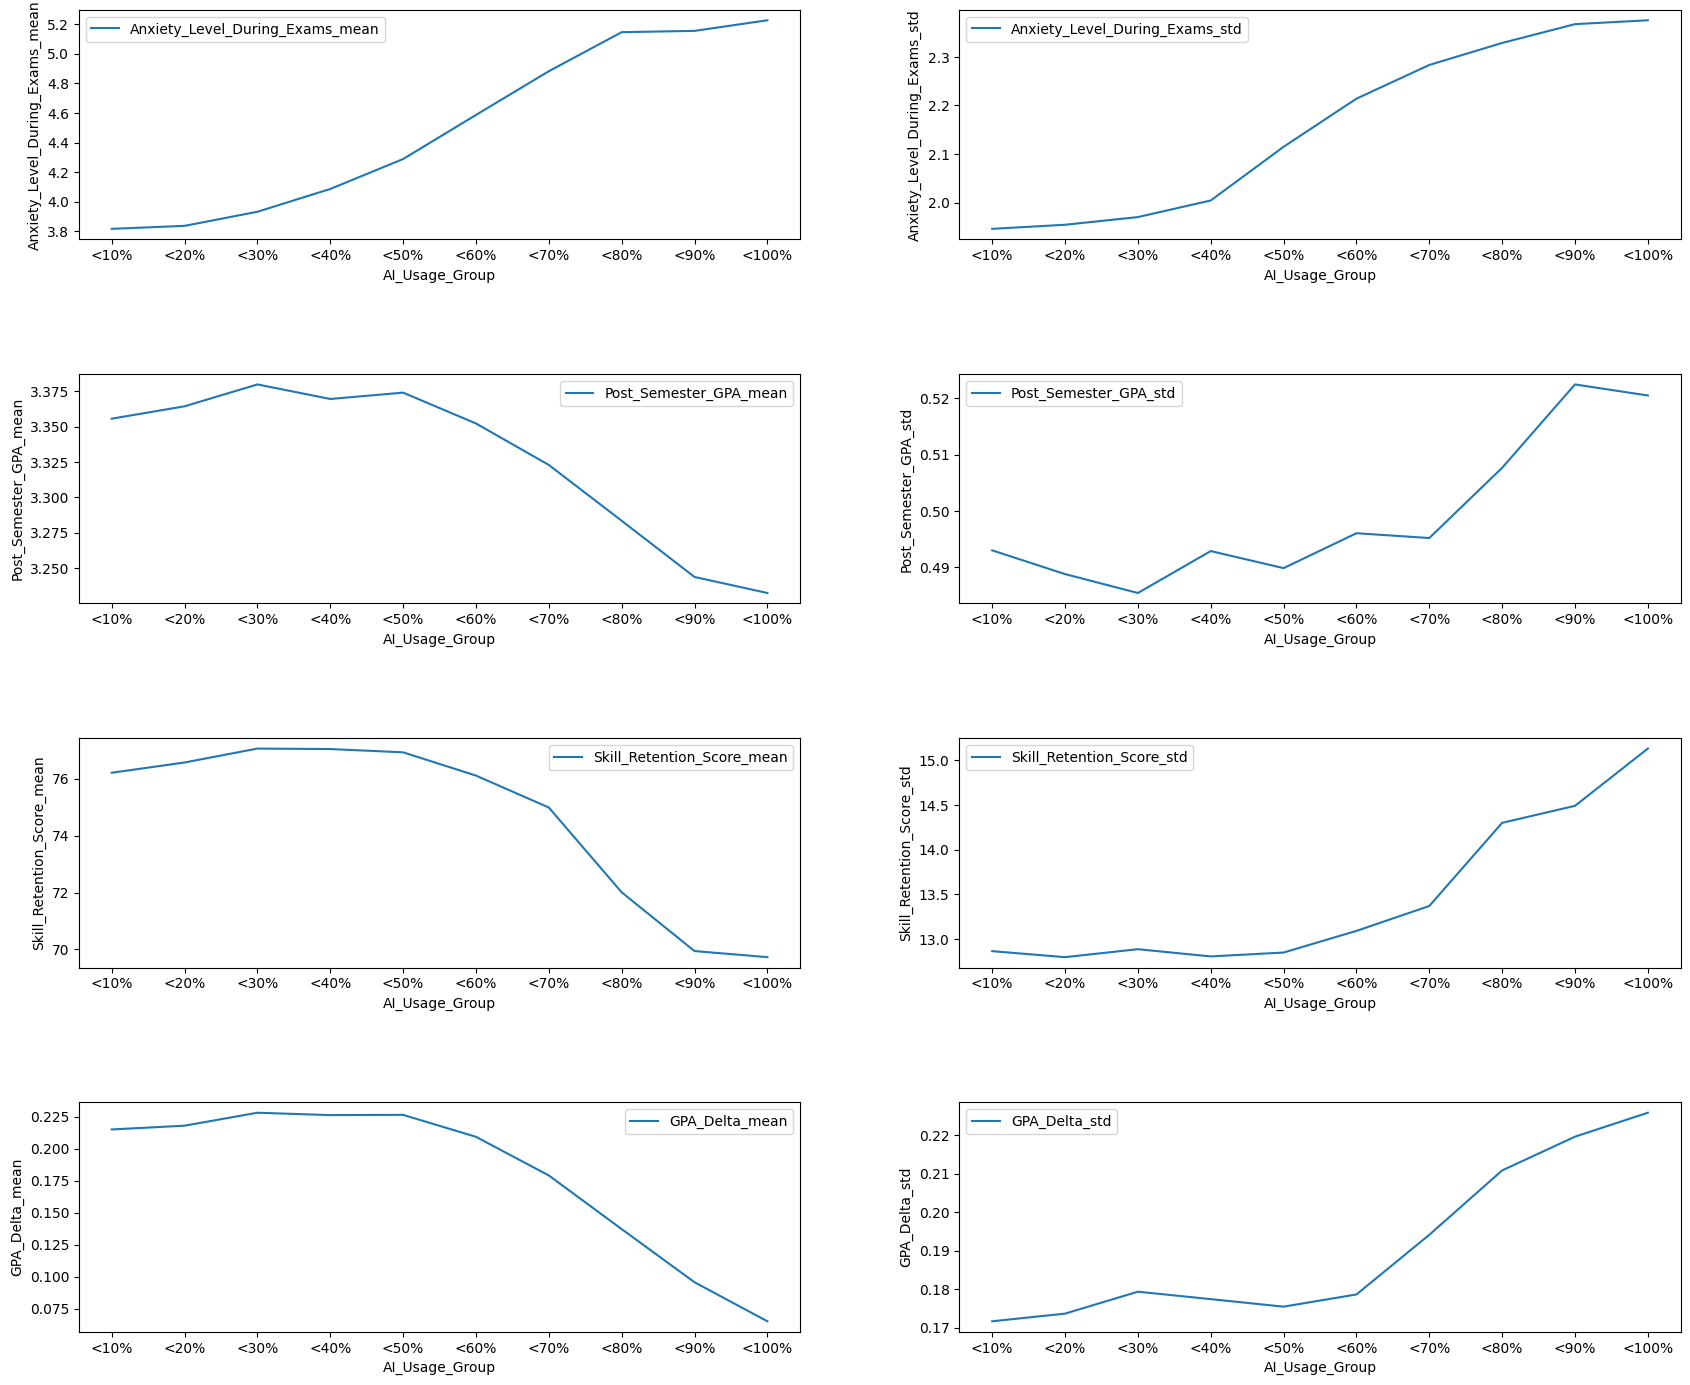

In [121]:
fig, axs = plt.subplots(4,2)
fig.tight_layout(pad=1)
fig.set_size_inches(18, 15, forward=True)

sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Anxiety_Level_During_Exams_mean', label='Anxiety_Level_During_Exams_mean', ax=axs[0,0])
sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Anxiety_Level_During_Exams_std', label='Anxiety_Level_During_Exams_std', ax=axs[0,1])

sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Post_Semester_GPA_mean', label='Post_Semester_GPA_mean', ax=axs[1,0])
sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Post_Semester_GPA_std', label='Post_Semester_GPA_std', ax=axs[1,1])

sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Skill_Retention_Score_mean', label='Skill_Retention_Score_mean', ax=axs[2,0])
sns.lineplot(aggregated_df,x='AI_Usage_Group',y='Skill_Retention_Score_std', label='Skill_Retention_Score_std', ax=axs[2,1])

sns.lineplot(aggregated_df,x='AI_Usage_Group',y='GPA_Delta_mean', label='GPA_Delta_mean', ax=axs[3,0])
sns.lineplot(aggregated_df,x='AI_Usage_Group',y='GPA_Delta_std', label='GPA_Delta_std', ax=axs[3,1])

plt.show()

Чем больше ИИ заменяет традиционное обучение, тем в среднем хуже оцена и больше ее разброс по студентам (возможно кто-то пользуется умело, кто-то плохо). Также растет тревожность на экзамене.

In [123]:
from bokeh.plotting import figure, show

p = figure(
    title="AI Usage Group vs GPA Delta",
    x_range=list(aggregated_df['AI_Usage_Group']),
    x_axis_label="AI Usage Group",
    y_axis_label="GPA Delta Mean"
)

p.vbar(
    x=list(aggregated_df['AI_Usage_Group']),
    top=list(aggregated_df['GPA_Delta_mean']),
    width=0.6
)

show(p)

Сохранение данных

In [204]:
df.to_pickle('../data/clean_data.pkl')

<h3>Что проводилось в очистке данных</h3>
- Удаление признака Student_ID<br>
- Даункаст признаков к менее затратным по памяти типам данных<br>
- Приведение к категориальным типам данных<br>
<h3>Создание новых признаков</h3>
- GPA_Delta - разница между оценкой в конце семестра и в начале<br>
- High_Risk_Student - студенты в зоне риска (высокий риск выгорания + высокая тревожность на экзамене)<br>
- AI_Usage_Percentage - процент использования ИИ в общем времени затраченном на учебу в неделю<br>
<h3>Выявленные закономерности</h3>
- AI_Usage_Percentage как и любой показатель использования ИИ влияет на успеваемость (Skill_Retention_Score, GPA_Delta, Post_Semester_GPA)<br>
- AI_Usage_Percentage и Perceived_AI_Dependency взаимосвязаны с уровнем стресса (High_Risk_Student, Burnout_Risk_Level, Anxiety_Level_During_Exams)<br>
- 
<h3>Общий вывод</h3>
<p>
Использование ИИ для обучения может положительно сказаться на успеваемости. Но важно помнить, что черезмерное и неправильное использование ИИ может сказать не только на успеваемости, но и на общем самочувствии, как следствие зависимости от ИИ.